PREDICTOR DEL GENERO MUSICAL DE UNA CANCIÓN USANDO TRANSFER LEARNING

In [ ]:
# Nos conectamos con Google Drive

from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pandas as pd

tracks = pd.read_csv("/content/drive/MyDrive/ProyectoIA/data/fma_metadata/tracks.csv", header=[0,1], index_col=0)
echonest = pd.read_csv("/content/drive/MyDrive/ProyectoIA/data/fma_metadata/echonest.csv", header=[0,1,2], index_col=0)
genres = pd.read_csv("/content/drive/MyDrive/ProyectoIA/data/fma_metadata/genres.csv")
features = pd.read_csv("/content/drive/MyDrive/ProyectoIA/data/fma_metadata/features.csv", header = [0,1,2], index_col = 0)

In [ ]:
tracks_small = tracks[tracks[("set","subset")] == "small"]
ids_small = tracks_small.index

features_small = features.loc[ids_small]

In [ ]:
objetivo = tracks_small[[("track", "genre_top")]]

Espectogramas


In [ ]:
import os
import librosa
import librosa.display
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import warnings
import gc

warnings.filterwarnings('ignore')

ruta_fma_small = '/content/drive/MyDrive/ProyectoIA/data/fma_data/fma_small'
ruta_tracks_csv = '/content/drive/MyDrive/ProyectoIA/data/fma_metadata/tracks.csv'
ruta_destino_espectrogramas = '/content/drive/MyDrive/ProyectoIA/ESPECTROGRAMAS_POR_GENERO'

print("📖 Cargando diccionario...")
tracks = pd.read_csv(ruta_tracks_csv, index_col=0, header=[0, 1])
generos_small = tracks[tracks[('set', 'subset')] == 'small'][('track', 'genre_top')].dropna()

def procesar_audio(ruta_mp3, track_id, genero):
    carpeta_genero = os.path.join(ruta_destino_espectrogramas, genero)
    if not os.path.exists(carpeta_genero):
        os.makedirs(carpeta_genero)

    ruta_imagen = os.path.join(carpeta_genero, f"{track_id}.png")

    if os.path.exists(ruta_imagen):
        return

    try:
        y, sr = librosa.load(ruta_mp3, duration=30, sr=22050)
        mel_spect = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=128)
        mel_spect_db = librosa.power_to_db(mel_spect, ref=np.max)

        fig = plt.figure(figsize=(10, 4))
        plt.axis('off')
        librosa.display.specshow(mel_spect_db, sr=sr, cmap='magma')
        plt.savefig(ruta_imagen, bbox_inches='tight', pad_inches=0)


        fig.clf()
        plt.close('all')

        del y, sr, mel_spect, mel_spect_db, fig
        gc.collect()

    except Exception as e:
        print(f"⚠️ Error con {track_id}: {e}")

print("🚀 Retomando el procesamiento...")
contador = 0

for raiz, carpetas, archivos in os.walk(ruta_fma_small):
    for archivo in archivos:
        if archivo.endswith('.mp3'):
            try:
                track_id = int(archivo.replace('.mp3', ''))
                if track_id in generos_small.index:
                    genero_cancion = generos_small.loc[track_id]
                    ruta_completa_mp3 = os.path.join(raiz, archivo)

                    procesar_audio(ruta_completa_mp3, track_id, genero_cancion)
                    contador += 1

                    if contador % 100 == 0:
                        print(f"🔄 Progreso desde que le diste a Play: {contador} espectrogramas...")

            except ValueError:
                pass

print("🏁 ¡Proceso terminado con éxito!")

Modelo usando los Espectogramas: Usamos un modelo ya entrenado para ver imágenes.

In [ ]:
import tensorflow as tf
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout, Input
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
import matplotlib.pyplot as plt

ruta_datos = '/content/drive/MyDrive/ProyectoIA/ESPECTROGRAMAS_POR_GENERO'
IMG_SIZE = (224, 224)
BATCH_SIZE = 32

print("Cargando datos de Entrenamiento...")
train_dataset = tf.keras.utils.image_dataset_from_directory(
    ruta_datos,
    shuffle=True,
    batch_size=BATCH_SIZE,
    image_size=IMG_SIZE,
    validation_split=0.2,
    subset='training',
    seed=42
)

print("Cargando datos de Validación...")
val_dataset = tf.keras.utils.image_dataset_from_directory(
    ruta_datos,
    shuffle=True,
    batch_size=BATCH_SIZE,
    image_size=IMG_SIZE,
    validation_split=0.2,
    subset='validation',
    seed=42
)

class_names = train_dataset.class_names
print(f"Géneros detectados: {class_names}")

AUTOTUNE = tf.data.AUTOTUNE
train_dataset = train_dataset.cache().prefetch(buffer_size=AUTOTUNE)
val_dataset = val_dataset.cache().prefetch(buffer_size=AUTOTUNE)

base_model = MobileNetV2(input_shape=IMG_SIZE + (3,),
                         include_top=False,
                         weights='imagenet')

base_model.trainable = False

inputs = Input(shape=IMG_SIZE + (3,))

x = preprocess_input(inputs)
x = base_model(x, training=False)
x = GlobalAveragePooling2D()(x)
x = Dropout(0.5)(x)
outputs = Dense(len(class_names), activation='softmax')(x)

model = Model(inputs, outputs)

model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

model.summary()

Cargando datos de Entrenamiento...
Found 7997 files belonging to 8 classes.
Using 6398 files for training.
Cargando datos de Validación...
Found 7997 files belonging to 8 classes.
Using 1599 files for validation.
Géneros detectados: ['Electronic', 'Experimental', 'Folk', 'Hip-Hop', 'Instrumental', 'International', 'Pop', 'Rock']
9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ true_divide (TrueDivide)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ subtract (Subtract)             │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 8)              │        10,248 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,268,232 (8.65 MB)

 Trainable params: 10,248 (40.03 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [ ]:
early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

EPOCHS = 20

print("🚀 Iniciando entrenamiento...")
history = model.fit(
    train_dataset,
    epochs=EPOCHS,
    validation_data=val_dataset,
    callbacks=[early_stop]
)
print("✅ Entrenamiento finalizado.")

🚀 Iniciando entrenamiento...
Epoch 1/20
200/200 ━━━━━━━━━━━━━━━━━━━━ 1240s 6s/step - accuracy: 0.2821 - loss: 2.0914 - val_accuracy: 0.4159 - val_loss: 1.5904
Epoch 2/20
200/200 ━━━━━━━━━━━━━━━━━━━━ 6s 30ms/step - accuracy: 0.4004 - loss: 1.6800 - val_accuracy: 0.4609 - val_loss: 1.5037
Epoch 3/20
200/200 ━━━━━━━━━━━━━━━━━━━━ 6s 32ms/step - accuracy: 0.4381 - loss: 1.5671 - val_accuracy: 0.4797 - val_loss: 1.4660
Epoch 4/20
200/200 ━━━━━━━━━━━━━━━━━━━━ 6s 30ms/step - accuracy: 0.4567 - loss: 1.5171 - val_accuracy: 0.4759 - val_loss: 1.4500
Epoch 5/20
200/200 ━━━━━━━━━━━━━━━━━━━━ 6s 32ms/step - accuracy: 0.4712 - loss: 1.4835 - val_accuracy: 0.4909 - val_loss: 1.4344
Epoch 6/20
200/200 ━━━━━━━━━━━━━━━━━━━━ 6s 30ms/step - accuracy: 0.4803 - loss: 1.4640 - val_accuracy: 0.4928 - val_loss: 1.4330
Epoch 7/20
200/200 ━━━━━━━━━━━━━━━━━━━━ 6s 31ms/step - accuracy: 0.4897 - loss: 1.4474 - val_accuracy: 0.4891 - val_loss: 1.4344
Epoch 8/20
200/200 ━━━━━━━━━━━━━━━━━━━━ 6s 30ms/step - accuracy: 0.

In [ ]:
print("Descongelando MobileNetV2 para Fine-Tuning...")

base_model.trainable = True

for layer in base_model.layers[:100]:
    layer.trainable = False

model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

early_stop_fine = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=4, restore_best_weights=True)

history_fine = model.fit(
    train_dataset,
    epochs=10, # 10 épocas más
    validation_data=val_dataset,
    callbacks=[early_stop_fine]
)

Descongelando MobileNetV2 para Fine-Tuning...
Epoch 1/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 68s 202ms/step - accuracy: 0.2246 - loss: 4.2808 - val_accuracy: 0.3308 - val_loss: 2.2879
Epoch 2/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 36s 48ms/step - accuracy: 0.3385 - loss: 1.9690 - val_accuracy: 0.3821 - val_loss: 1.9150
Epoch 3/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 10s 48ms/step - accuracy: 0.4092 - loss: 1.7233 - val_accuracy: 0.4028 - val_loss: 1.7902
Epoch 4/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 9s 46ms/step - accuracy: 0.4430 - loss: 1.5800 - val_accuracy: 0.4184 - val_loss: 1.7018
Epoch 5/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 10s 48ms/step - accuracy: 0.4766 - loss: 1.4838 - val_accuracy: 0.4409 - val_loss: 1.6447
Epoch 6/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 11s 54ms/step - accuracy: 0.5161 - loss: 1.3730 - val_accuracy: 0.4578 - val_loss: 1.5806
Epoch 7/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 10s 48ms/step - accuracy: 0.5339 - loss: 1.2963 - val_accuracy: 0.4816 - val_loss: 1.5352
Epoch 8/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 10s 

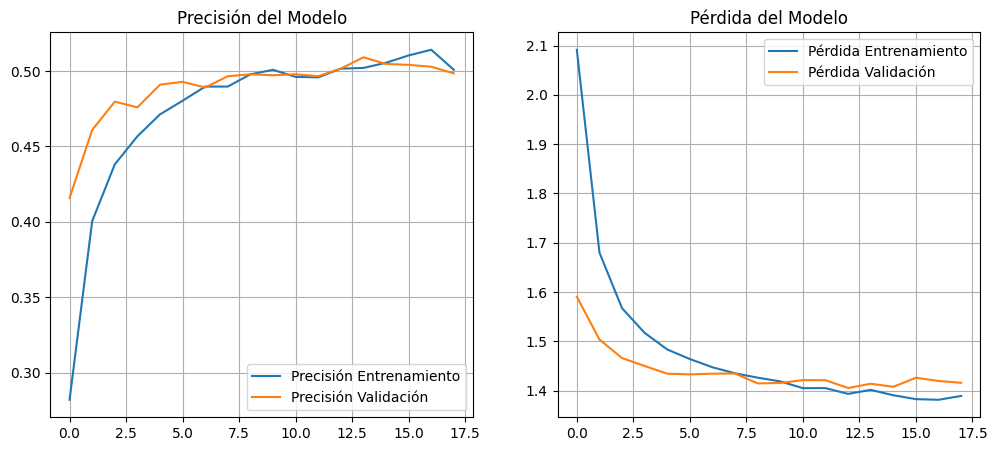

💾 Modelo guardado en: /content/drive/MyDrive/ProyectoIA/modelo_transfer1.h5


In [ ]:
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']

epochs_range = range(len(acc))

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Precisión Entrenamiento')
plt.plot(epochs_range, val_acc, label='Precisión Validación')
plt.legend(loc='lower right')
plt.title('Precisión del Modelo')
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Pérdida Entrenamiento')
plt.plot(epochs_range, val_loss, label='Pérdida Validación')
plt.legend(loc='upper right')
plt.title('Pérdida del Modelo')
plt.grid(True)

plt.show()

ruta_guardado = '/content/drive/MyDrive/ProyectoIA/modelo_transfer1.h5'
model.save(ruta_guardado)
print(f"💾 Modelo guardado en: {ruta_guardado}")

Modelo usando YamNet (Entrenada escuchando audios)

In [ ]:
import os
import numpy as np
import pandas as pd
import tensorflow as tf
import tensorflow_hub as hub
import librosa
import gc

print("Cargando YAMNet...")
yamnet_model_handle = 'https://tfhub.dev/google/yamnet/1'
yamnet_model = hub.load(yamnet_model_handle)

ruta_fma_small = '/content/drive/MyDrive/ProyectoIA/data/fma_data/fma_small'
ruta_tracks_csv = '/content/drive/MyDrive/ProyectoIA/data/fma_metadata/tracks.csv'
ruta_embeddings = '/content/drive/MyDrive/ProyectoIA/fma_yamnet_embeddings.npz'

tracks = pd.read_csv(ruta_tracks_csv, index_col=0, header=[0, 1])
generos_small = tracks[tracks[('set', 'subset')] == 'small'][('track', 'genre_top')].dropna()

generos_unicos = generos_small.unique()
mapa_generos = {genero: i for i, genero in enumerate(generos_unicos)}

Cargando YAMNet...


In [ ]:
import os
import numpy as np
import pandas as pd
import tensorflow as tf
import tensorflow_hub as hub
import librosa
import gc

print("Cargando YAMNet...")
yamnet_model_handle = 'https://tfhub.dev/google/yamnet/1'
yamnet_model = hub.load(yamnet_model_handle)

ruta_fma_small = '/content/drive/MyDrive/ProyectoIA/data/fma_data/fma_small'
ruta_tracks_csv = '/content/drive/MyDrive/ProyectoIA/data/fma_metadata/tracks.csv'
ruta_embeddings = '/content/drive/MyDrive/ProyectoIA/fma_yamnet_embeddings.npz'

tracks = pd.read_csv(ruta_tracks_csv, index_col=0, header=[0, 1])
generos_small = tracks[tracks[('set', 'subset')] == 'small'][('track', 'genre_top')].dropna()

generos_unicos = generos_small.unique()
mapa_generos = {genero: i for i, genero in enumerate(generos_unicos)}

def extraer_embedding(ruta_mp3):
    # YAMNet exige estrictamente audio a 16000 Hz, mono
    y, sr = librosa.load(ruta_mp3, sr=16000, mono=True, duration=30)

    # Convertir a tensor de TensorFlow
    waveform = tf.convert_to_tensor(y, dtype=tf.float32)

    # YAMNet devuelve 3 cosas: predicciones, embeddings y el espectrograma
    _, embeddings, _ = yamnet_model(waveform)

    # YAMNet da un embedding por cada medio segundo.
    # Calculamos la media de todos para tener 1 solo vector por canción
    embedding_promedio = tf.reduce_mean(embeddings, axis=0).numpy()
    return embedding_promedio

X_data = []
y_labels = []

contador = 0
print("🎧 Extrayendo conocimiento con YAMNet (esto tomará un rato)...")

for raiz, carpetas, archivos in os.walk(ruta_fma_small):
    for archivo in archivos:
        if archivo.endswith('.mp3'):
            try:
                track_id = int(archivo.replace('.mp3', ''))
                if track_id in generos_small.index:
                    genero_cancion = generos_small.loc[track_id]
                    ruta_completa_mp3 = os.path.join(raiz, archivo)

                    vector = extraer_embedding(ruta_completa_mp3)

                    X_data.append(vector)
                    y_labels.append(mapa_generos[genero_cancion])

                    contador += 1
                    if contador % 100 == 0:
                        print(f"✅ {contador} canciones procesadas por YAMNet...")
                        gc.collect()

            except Exception as e:
                pass

np.savez(ruta_embeddings, X=np.array(X_data), y=np.array(y_labels))
print("🏁 ¡Proceso completado! Embeddings guardados en Drive.")

Cargando YAMNet...
🎧 Extrayendo conocimiento con YAMNet (esto tomará un rato)...
✅ 100 canciones procesadas por YAMNet...
✅ 200 canciones procesadas por YAMNet...
✅ 300 canciones procesadas por YAMNet...
✅ 400 canciones procesadas por YAMNet...


KeyboardInterrupt: 

Tenemos 7997 canciones, cada una representada por 1024 características.


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 512)            │       524,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 8)              │         2,056 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 658,184 (2.51 MB)

 Trainable params: 658,184 (2.51 MB)

 Non-trainable params: 0 (0.00 B)

🚀 Entrenando el clasificador...
Epoch 1/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 6s 14ms/step - accuracy: 0.5554 - loss: 1.3350 - val_accuracy: 0.6206 - val_loss: 1.1698
Epoch 2/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.6009 - loss: 1.2158 - val_accuracy: 0.6144 - val_loss: 1.1446
Epoch 3/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.6114 - loss: 1.1730 - val_accuracy: 0.6300 - val_loss: 1.1106
Epoch 4/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.6258 - loss: 1.1818 - val_accuracy: 0.6244 - val_loss: 1.0869
Epoch 5/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.6262 - loss: 1.1246 - val_accuracy: 0.6263 - val_loss: 1.1010
Epoch 6/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.6394 - loss: 1.1101 - val_accuracy: 0.6306 - val_loss: 1.0823
Epoch 7/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.6451 - loss: 1.0712 - val_accuracy: 0.6344 - val_loss: 1.0819
Epoch 8/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.6478 

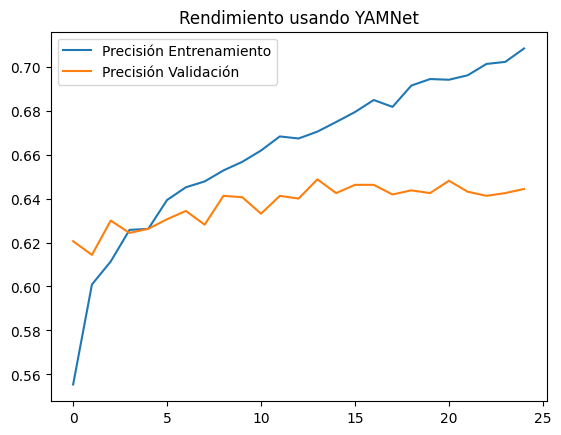

In [ ]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

# 1. Cargar los datos pre-procesados
ruta_embeddings = '/content/drive/MyDrive/ProyectoIA/fma_yamnet_embeddings.npz'
datos = np.load(ruta_embeddings)
X = datos['X']
y = datos['y']

print(f"Tenemos {X.shape[0]} canciones, cada una representada por {X.shape[1]} características.")

# 2. Dividir en Entrenamiento y Validación
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. Crear el modelo

model = Sequential([
    Dense(512, activation='relu', input_shape=(1024,)),
    Dropout(0.5),
    Dense(256, activation='relu'),
    Dropout(0.4),
    Dense(8, activation='softmax')
])

model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

model.summary()

# 4. Entrenar el modelo
early_stop = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

print("🚀 Entrenando el clasificador...")
history = model.fit(
    X_train, y_train,
    epochs=50,
    batch_size=32,
    validation_data=(X_val, y_val),
    callbacks=[early_stop]
)

# 5. Visualizar resultados
plt.plot(history.history['accuracy'], label='Precisión Entrenamiento')
plt.plot(history.history['val_accuracy'], label='Precisión Validación')
plt.title('Rendimiento usando YAMNet')
plt.legend()
plt.show()

Matriz de Confusión

🧠 Pensando las predicciones...
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step


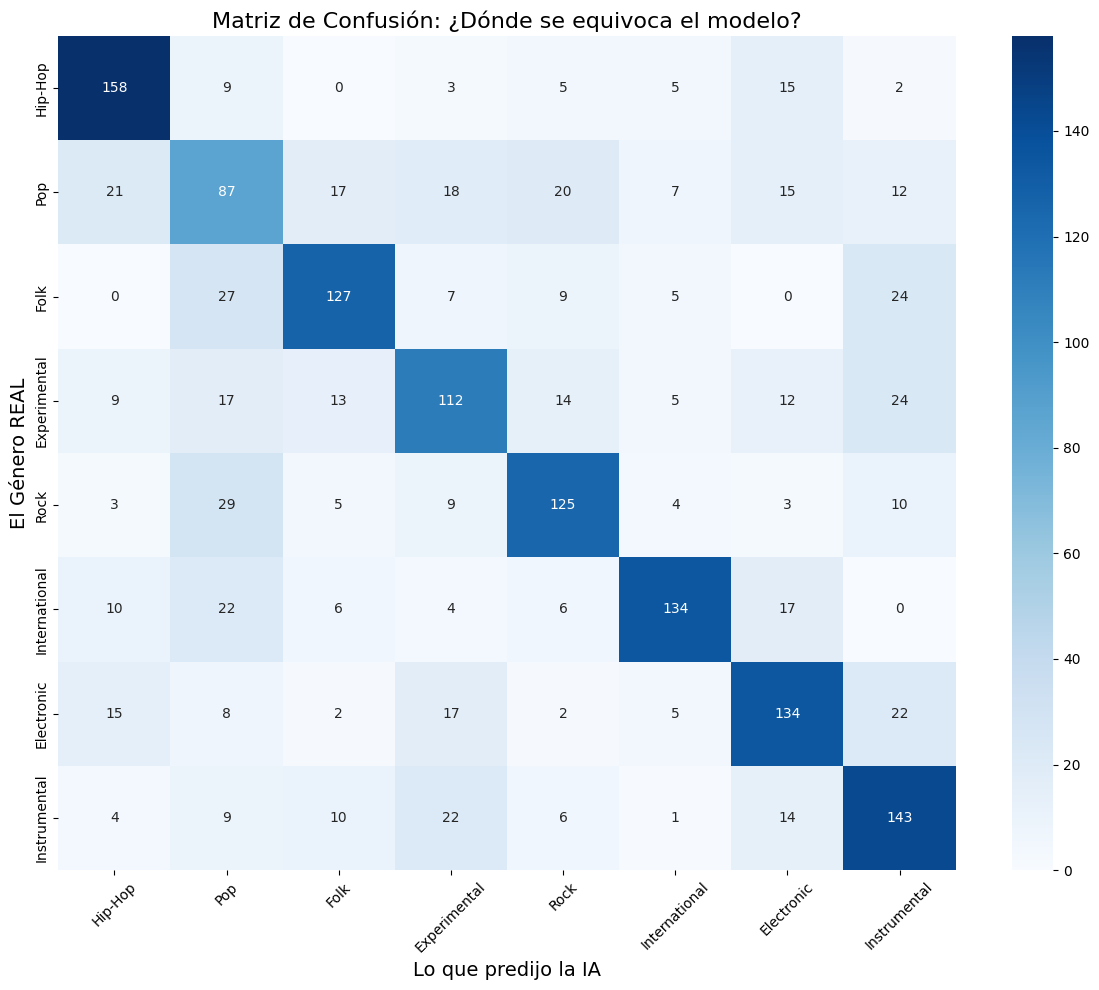

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

nombres_generos = {valor: clave for clave, valor in mapa_generos.items()}
lista_etiquetas = [nombres_generos[i] for i in range(8)]

print("🧠 Pensando las predicciones...")
predicciones_probs = model.predict(X_val)

predicciones_finales = np.argmax(predicciones_probs, axis=1)

cm = confusion_matrix(y_val, predicciones_finales)

plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=lista_etiquetas,
            yticklabels=lista_etiquetas)

plt.title('Matriz de Confusión: ¿Dónde se equivoca el modelo?', fontsize=16)
plt.xlabel('Lo que predijo la IA', fontsize=14)
plt.ylabel('El Género REAL', fontsize=14)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Predicción

In [ ]:
ruta_nueva_cancion = '/content/drive/MyDrive/ProyectoIA/Tonight_Again.mp3'

print("🎧 YAMNet está escuchando tu canción...")
nuevo_vector = extraer_embedding(ruta_nueva_cancion)

nuevo_vector_adaptado = np.expand_dims(nuevo_vector, axis=0)

print("🧠 Analizando patrones musicales...")
probabilidades = model.predict(nuevo_vector_adaptado)[0]

lista_etiquetas = ['Electronic', 'Experimental', 'Folk', 'Hip-Hop', 'Instrumental', 'International', 'Pop', 'Rock']

indice_ganador = np.argmax(probabilidades)
genero_ganador = lista_etiquetas[indice_ganador]
seguridad = probabilidades[indice_ganador] * 100

print("-" * 40)
print(f"🎸 ¡PREDICCIÓN FINALIZADA!")
print(f"El modelo cree que esta canción es: **{genero_ganador.upper()}**")
print(f"Nivel de seguridad: {seguridad:.2f}%\n")

print("📊 Top 3 de géneros más probables:")
top_3_indices = np.argsort(probabilidades)[-3:][::-1]

for i in top_3_indices:
    nombre = lista_etiquetas[i]
    prob = probabilidades[i] * 100
    print(f"  - {nombre}: {prob:.2f}%")
print("-" * 40)

🎧 YAMNet está escuchando tu canción...
🧠 Analizando patrones musicales...
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 212ms/step
----------------------------------------
🎸 ¡PREDICCIÓN FINALIZADA!
El modelo cree que esta canción es: **EXPERIMENTAL**
Nivel de seguridad: 80.03%

📊 Top 3 de géneros más probables:
  - Experimental: 80.03%
  - Instrumental: 10.19%
  - Hip-Hop: 4.11%
----------------------------------------


Guardamos el Modelo

In [ ]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
import os

ruta_embeddings = '/content/drive/MyDrive/ProyectoIA/fma_yamnet_embeddings.npz'
ruta_modelo = '/content/drive/MyDrive/ProyectoIA/modelo_yamnet.keras'

print("1. Cargando tus datos...")
datos = np.load(ruta_embeddings)
X, y = datos['X'], datos['y']

print("2. Creando y entrenando el modelo en modo turbo (unos segundos)...")
model = Sequential([
    Dense(512, activation='relu', input_shape=(1024,)),
    Dropout(0.5),
    Dense(256, activation='relu'),
    Dropout(0.4),
    Dense(8, activation='softmax')
])

model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

model.fit(X, y, epochs=25, batch_size=32, verbose=0)

print("3. Guardando el modelo permanentemente en tu Drive...")
model.save(ruta_modelo)
model.save_weights('/content/drive/MyDrive/ProyectoIA/pesos_yamnet.weights.h5')

if os.path.exists(ruta_modelo):
    print(f"✅ ¡ÉXITO! El archivo ha sido creado en: {ruta_modelo}")
    print("Ya puedes usar el script de predicción sin problemas.")
else:
    print("⚠️ Mmm, Google Drive está tardando en sincronizar. Revisa tu carpeta manualmente.")

1. Cargando tus datos...
2. Creando y entrenando el modelo en modo turbo (unos segundos)...
3. Guardando el modelo permanentemente en tu Drive...
✅ ¡ÉXITO! El archivo ha sido creado en: /content/drive/MyDrive/ProyectoIA/modelo_yamnet.keras
Ya puedes usar el script de predicción sin problemas.
